In [ ]:
pip install pandas numpy scikit-learn shap openpyxl matplotlib


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_hcc_may.xlsx to data_hcc_may.xlsx


Đang đọc dữ liệu từ data_hcc_may.xlsx...
Bắt đầu chạy đánh giá ngẫu nhiên 30 lần...
Đã hoàn thành 5/30 lần lặp...
Đã hoàn thành 10/30 lần lặp...
Đã hoàn thành 15/30 lần lặp...
Đã hoàn thành 20/30 lần lặp...
Đã hoàn thành 25/30 lần lặp...
Đã hoàn thành 30/30 lần lặp...

--- KẾT QUẢ ĐỘ QUAN TRỌNG ĐẶC TRƯNG (SHAP MEAN) ---
AFP: 0.1039
HBsAg: 0.1034
APRI: 0.0612
CEA: 0.0596
AST: 0.0363
ALT: 0.0271
Platelets: 0.0269
FIB-4: 0.0229
INR: 0.0136
Total_Bil: 0.0107
CA19-9: 0.0094
Dir_Bil: 0.0077
Age: 0.0043
Gender: 0.0037
Ure: 0.0037
Creatinine: 0.0033
AST/ALT: 0.0031
Albumin: 0.0030
Glucose: 0.0028
HCVAb: 0.0021


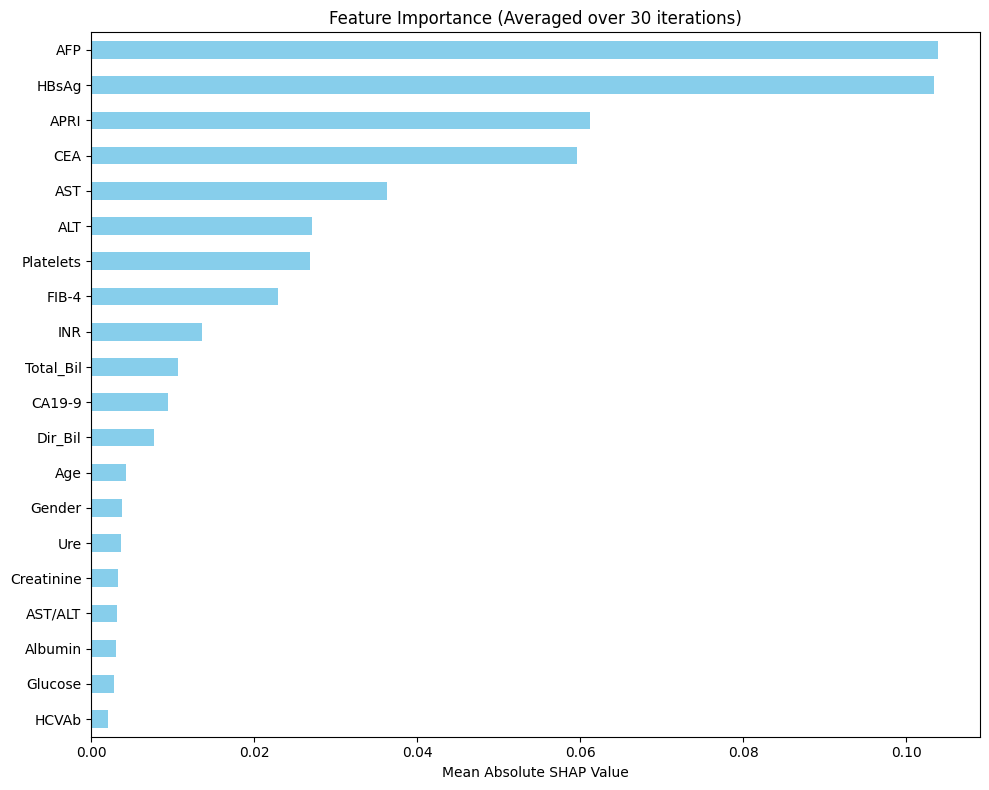


Vẽ biểu đồ phân bố SHAP (Bee Swarm plot)...


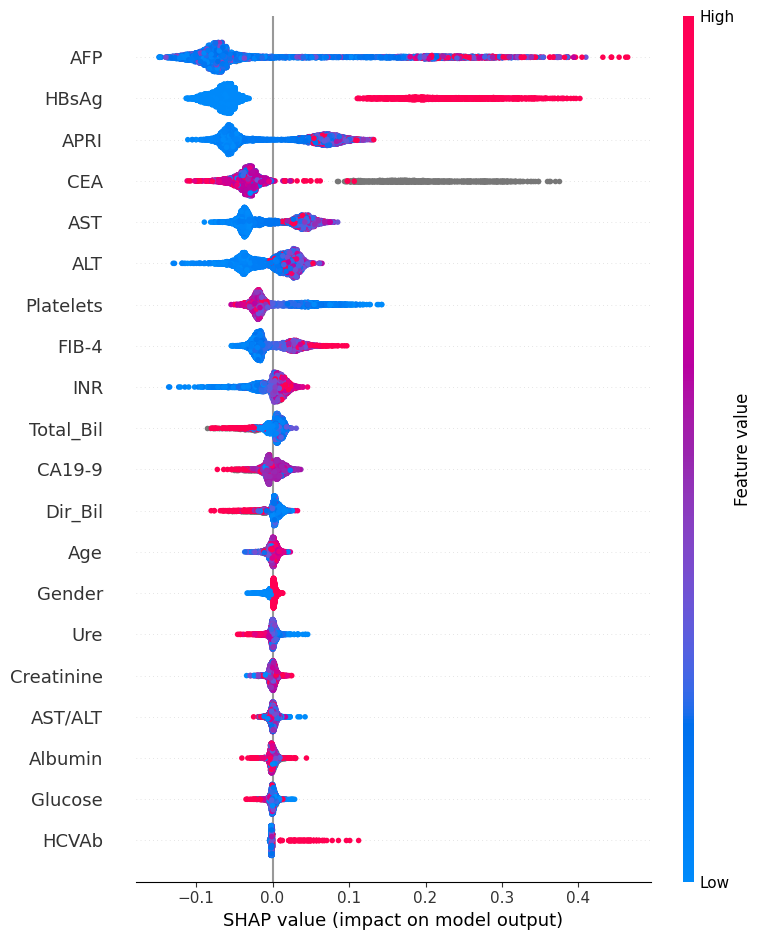

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 1. TẢI VÀ CHUẨN BỊ DỮ LIỆU
print("Đang đọc dữ liệu từ data_hcc_may.xlsx...")
df = pd.read_excel('data_hcc_may.xlsx')

TARGET_COLUMN = 'label'
X = df.drop(columns=[TARGET_COLUMN, 'record_id'])
y = df[TARGET_COLUMN]
feature_names = X.columns.tolist()

# 2. CẤU HÌNH THÔNG SỐ VÒNG LẶP
n_iterations = 30
test_size = 0.2
shap_importance_df = pd.DataFrame(index=feature_names)
all_shap_values = []
all_X_test_scaled = []

print(f"Bắt đầu chạy đánh giá ngẫu nhiên {n_iterations} lần...")

# 3. TIẾN HÀNH LẶP 30 LẦN
for i in range(n_iterations):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=i)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = RandomForestClassifier(criterion='gini', max_depth=7, max_features='sqrt', n_estimators=250, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Sử dụng TreeExplainer - Để tránh tràn bộ nhớ, ta giới hạn dữ liệu tính toán SHAP
    explainer = shap.TreeExplainer(model)
    # Tính toán trực tiếp trên X_test_scaled
    shap_values = explainer.shap_values(X_test_scaled, check_additivity=False)

    if isinstance(shap_values, list):
        shap_values_class1 = shap_values[1]
    else:
        # Cấu trúc mới của SHAP cho binary classifier có thể là (samples, features, 2)
        if len(shap_values.shape) == 3:
            shap_values_class1 = shap_values[:, :, 1]
        else:
            shap_values_class1 = shap_values

    mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)
    shap_importance_df[f'Iter_{i+1}'] = mean_abs_shap

    all_shap_values.append(shap_values_class1)
    all_X_test_scaled.append(X_test_scaled)

    if (i + 1) % 5 == 0:
        print(f"Đã hoàn thành {i + 1}/{n_iterations} lần lặp...")

# 4. TỔNG HỢP KẾT QUẢ
print("\n--- KẾT QUẢ ĐỘ QUAN TRỌNG ĐẶC TRƯNG (SHAP MEAN) ---")
shap_importance_df['Mean_SHAP_30_Iters'] = shap_importance_df.iloc[:, :n_iterations].mean(axis=1)
final_sorted_importance = shap_importance_df['Mean_SHAP_30_Iters'].sort_values(ascending=False)
for feature, value in final_sorted_importance.items():
    print(f"{feature}: {value:.4f}")

# Biểu đồ thanh
plt.figure(figsize=(10, 8))
final_sorted_importance.sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.xlabel("Mean Absolute SHAP Value")
plt.title(f"Feature Importance (Averaged over {n_iterations} iterations)")
plt.tight_layout()
plt.show()

# Biểu đồ Bee Swarm
combined_shap_values = np.vstack(all_shap_values)
combined_X_test = np.vstack(all_X_test_scaled)
print("\nVẽ biểu đồ phân bố SHAP (Bee Swarm plot)...")
shap.summary_plot(combined_shap_values, features=combined_X_test, feature_names=feature_names)

# Giải thích nhóm HCC

Đang đọc dữ liệu từ data_hcc_may.xlsx...
Bắt đầu chạy đánh giá ngẫu nhiên 30 lần CỤC BỘ CHO NHÓM HCC...
Đã hoàn thành 5/30 lần lặp...
Đã hoàn thành 10/30 lần lặp...
Đã hoàn thành 15/30 lần lặp...
Đã hoàn thành 20/30 lần lặp...
Đã hoàn thành 25/30 lần lặp...
Đã hoàn thành 30/30 lần lặp...
Đang tổng hợp kết quả cho nhóm HCC...


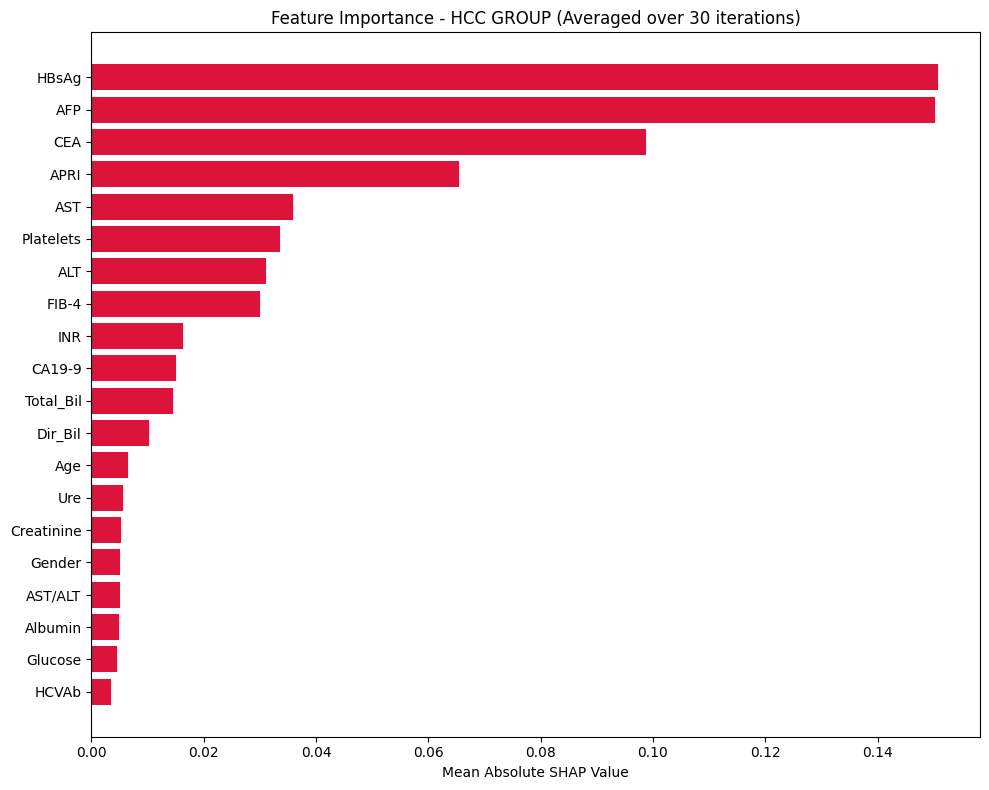

Vẽ biểu đồ Bee Swarm cho nhóm HCC...


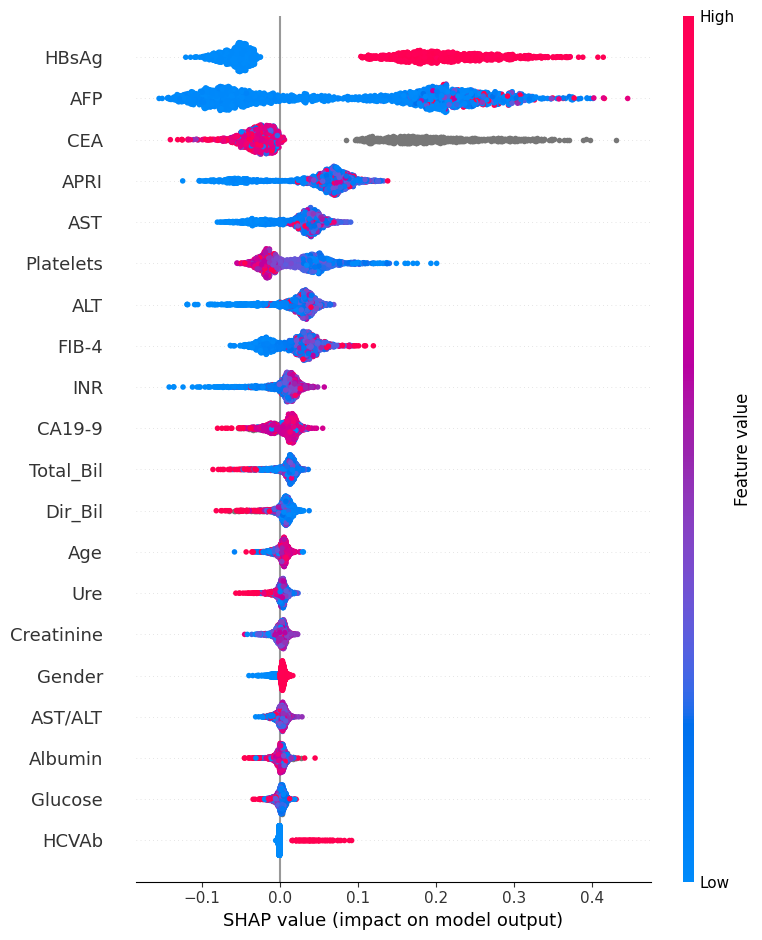

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import gc

# 1. TẢI VÀ CHUẨN BỊ DỮ LIỆU
print("Đang đọc dữ liệu từ data_hcc_may.xlsx...")
df = pd.read_excel('data_hcc_may.xlsx')
df = df.drop_duplicates()

TARGET_COLUMN = 'label'
X = df.drop(columns=[TARGET_COLUMN, 'record_id'])
y = df[TARGET_COLUMN]
feature_names = X.columns.tolist()

# 2. CẤU HÌNH THÔNG SỐ VÒNG LẶP
n_iterations = 30
test_size = 0.2
hcc_shap_importance_df = pd.DataFrame(index=feature_names)
all_hcc_shap_values = []
all_X_test_hcc_scaled = []

print(f"Bắt đầu chạy đánh giá ngẫu nhiên {n_iterations} lần CỤC BỘ CHO NHÓM HCC...")

# 3. TIẾN HÀNH LẶP 30 LẦN
for i in range(n_iterations):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=i)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train_scaled, y_train)

    hcc_mask = (y_test == 1).values
    X_test_hcc_scaled = X_test_scaled[hcc_mask]

    if X_test_hcc_scaled.shape[0] > 0:
        explainer = shap.TreeExplainer(model)
        # Sử dụng check_additivity=False để tránh lỗi làm tròn và tiết kiệm tài nguyên
        shap_values = explainer.shap_values(X_test_hcc_scaled, check_additivity=False)

        if isinstance(shap_values, list):
            shap_values_class1 = shap_values[1]
        elif len(shap_values.shape) == 3:
            shap_values_class1 = shap_values[:, :, 1]
        else:
            shap_values_class1 = shap_values

        hcc_shap_importance_df[f'Iter_{i+1}'] = np.abs(shap_values_class1).mean(axis=0)
        all_hcc_shap_values.append(shap_values_class1)
        all_X_test_hcc_scaled.append(X_test_hcc_scaled)

    # Giải phóng bộ nhớ
    del model
    gc.collect()

    if (i + 1) % 5 == 0:
        print(f"Đã hoàn thành {i + 1}/{n_iterations} lần lặp...")

# 4. TỔNG HỢP VÀ TRỰC QUAN HÓA
print("Đang tổng hợp kết quả cho nhóm HCC...")
hcc_shap_importance_df['Mean_SHAP_HCC'] = hcc_shap_importance_df.iloc[:, :n_iterations].mean(axis=1)
final_hcc_importance = hcc_shap_importance_df[['Mean_SHAP_HCC']].sort_values(by='Mean_SHAP_HCC', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(final_hcc_importance.index, final_hcc_importance['Mean_SHAP_HCC'], color='crimson')
plt.xlabel("Mean Absolute SHAP Value")
plt.title(f"Feature Importance - HCC GROUP (Averaged over {n_iterations} iterations)")
plt.tight_layout()
plt.show()

combined_hcc_shap_values = np.vstack(all_hcc_shap_values)
combined_X_test_hcc = np.vstack(all_X_test_hcc_scaled)
print("Vẽ biểu đồ Bee Swarm cho nhóm HCC...")
shap.summary_plot(combined_hcc_shap_values, features=combined_X_test_hcc, feature_names=feature_names)

# Giải thích cục bộ nhóm NonHCC

Đang đọc dữ liệu từ data_hcc_may.xlsx...
Bắt đầu chạy đánh giá ngẫu nhiên 30 lần CỤC BỘ CHO NHÓM NonHCC...
Đã hoàn thành 5/30 lần lặp...
Đã hoàn thành 10/30 lần lặp...
Đã hoàn thành 15/30 lần lặp...
Đã hoàn thành 20/30 lần lặp...
Đã hoàn thành 25/30 lần lặp...
Đã hoàn thành 30/30 lần lặp...
Đang tổng hợp kết quả cho nhóm NonHCC...


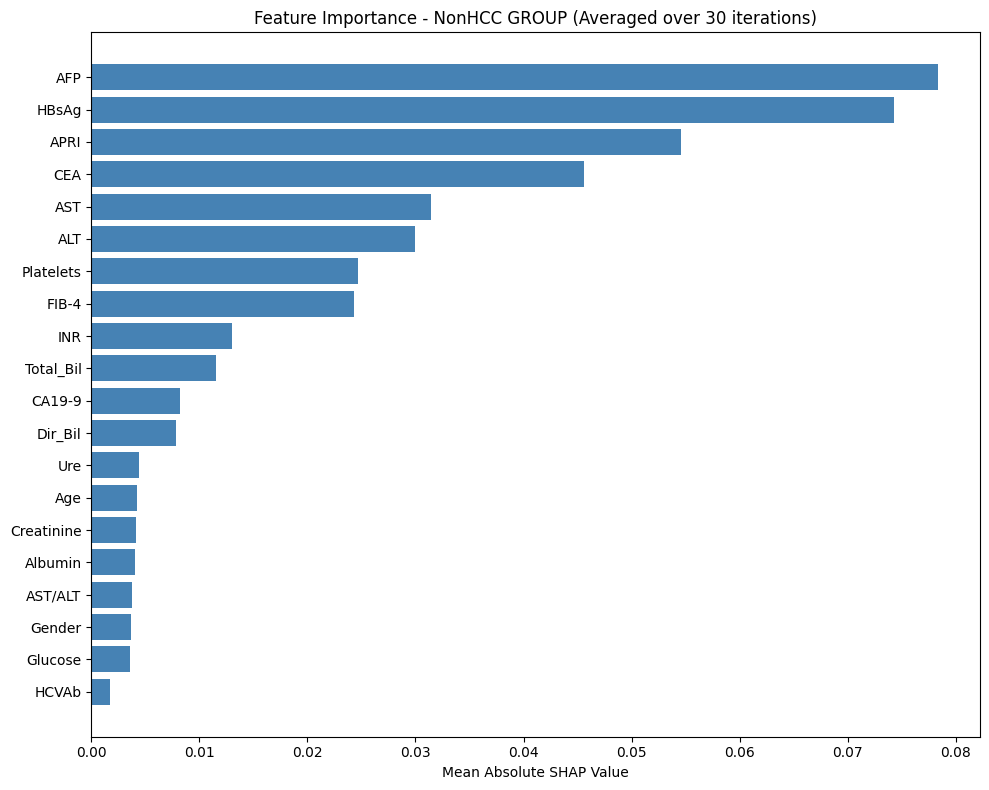

Vẽ biểu đồ Bee Swarm cho nhóm NonHCC...


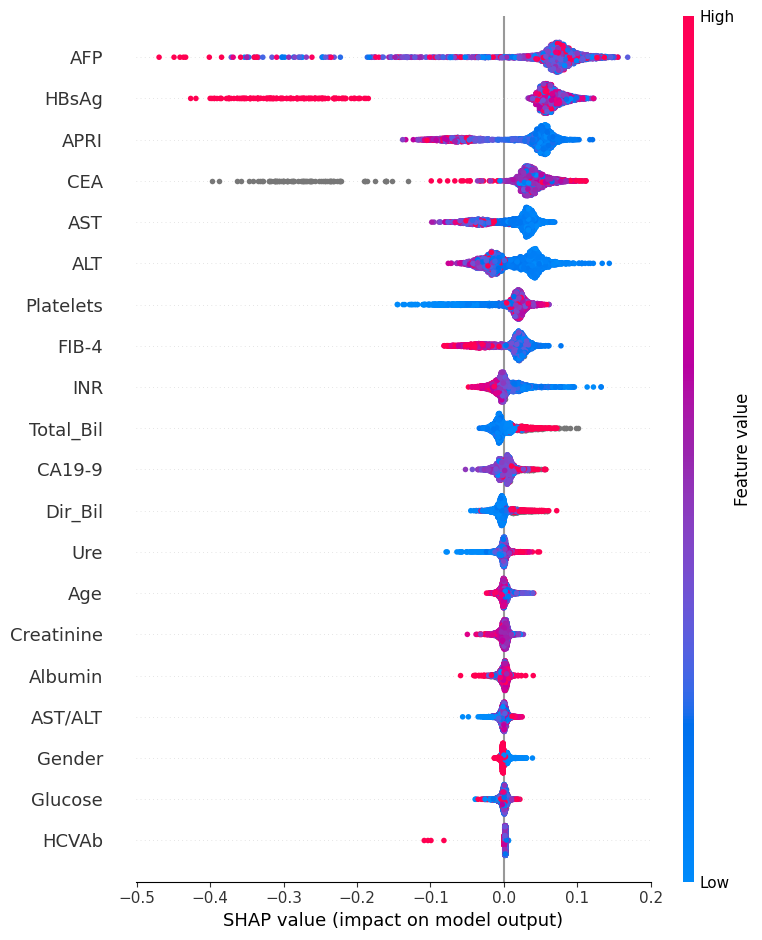

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import gc

# 1. TẢI VÀ CHUẨN BỊ DỮ LIỆU
print("Đang đọc dữ liệu từ data_hcc_may.xlsx...")
df = pd.read_excel('data_hcc_may.xlsx')
df = df.drop_duplicates()

TARGET_COLUMN = 'label'
X = df.drop(columns=[TARGET_COLUMN, 'record_id'])
y = df[TARGET_COLUMN]
feature_names = X.columns.tolist()

# 2. CẤU HÌNH THÔNG SỐ VÒNG LẶP
n_iterations = 30
test_size = 0.2
nonhcc_shap_importance_df = pd.DataFrame(index=feature_names)
all_nonhcc_shap_values = []
all_X_test_nonhcc_scaled = []

print(f"Bắt đầu chạy đánh giá ngẫu nhiên {n_iterations} lần CỤC BỘ CHO NHÓM NonHCC...")

# 3. TIẾN HÀNH LẶP 30 LẦN
for i in range(n_iterations):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=i)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train_scaled, y_train)

    # --- THAY ĐỔI 1: LỌC NHÓM NonHCC (Nhãn 0) ---
    nonhcc_mask = (y_test == 0).values
    X_test_nonhcc_scaled = X_test_scaled[nonhcc_mask]

    if X_test_nonhcc_scaled.shape[0] > 0:
        explainer = shap.TreeExplainer(model)
        # Sử dụng check_additivity=False để tránh lỗi làm tròn và tiết kiệm tài nguyên
        shap_values = explainer.shap_values(X_test_nonhcc_scaled, check_additivity=False)

        # --- THAY ĐỔI 2: LẤY SHAP VALUES CỦA CLASS 0 (NonHCC) ---
        if isinstance(shap_values, list):
            shap_values_target = shap_values[0]
        elif len(shap_values.shape) == 3:
            shap_values_target = shap_values[:, :, 0]
        else:
            shap_values_target = shap_values

        nonhcc_shap_importance_df[f'Iter_{i+1}'] = np.abs(shap_values_target).mean(axis=0)
        all_nonhcc_shap_values.append(shap_values_target)
        all_X_test_nonhcc_scaled.append(X_test_nonhcc_scaled)

    # Giải phóng bộ nhớ
    del model
    gc.collect()

    if (i + 1) % 5 == 0:
        print(f"Đã hoàn thành {i + 1}/{n_iterations} lần lặp...")

# 4. TỔNG HỢP VÀ TRỰC QUAN HÓA
print("Đang tổng hợp kết quả cho nhóm NonHCC...")
nonhcc_shap_importance_df['Mean_SHAP_NonHCC'] = nonhcc_shap_importance_df.iloc[:, :n_iterations].mean(axis=1)
final_nonhcc_importance = nonhcc_shap_importance_df[['Mean_SHAP_NonHCC']].sort_values(by='Mean_SHAP_NonHCC', ascending=True)

plt.figure(figsize=(10, 8))
# Đổi màu thành 'steelblue' để dễ phân biệt trực quan với biểu đồ HCC (màu crimson)
plt.barh(final_nonhcc_importance.index, final_nonhcc_importance['Mean_SHAP_NonHCC'], color='steelblue')
plt.xlabel("Mean Absolute SHAP Value")
plt.title(f"Feature Importance - NonHCC GROUP (Averaged over {n_iterations} iterations)")
plt.tight_layout()
plt.show()

combined_nonhcc_shap_values = np.vstack(all_nonhcc_shap_values)
combined_X_test_nonhcc = np.vstack(all_X_test_nonhcc_scaled)

print("Vẽ biểu đồ Bee Swarm cho nhóm NonHCC...")
shap.summary_plot(combined_nonhcc_shap_values, features=combined_X_test_nonhcc, feature_names=feature_names)